In [2]:
import scanpy as sc
import matplotlib.pyplot as plt
sc.settings.verbosity = 4
sc.settings.figdir = '../results/'
adata = sc.read_h5ad('../data/pbmc3k_preprocessed.h5ad')

computing PCA
    with n_comps=50
    finished (0:00:00)
    and added
    'X_pca', the PCA coordinates (adata.obs)
    'PCs', the loadings (adata.varm)
    'pca_variance', the variance / eigenvalues (adata.uns['pca'])
    'pca_variance_ratio', the variance ratio (adata.uns['pca'])


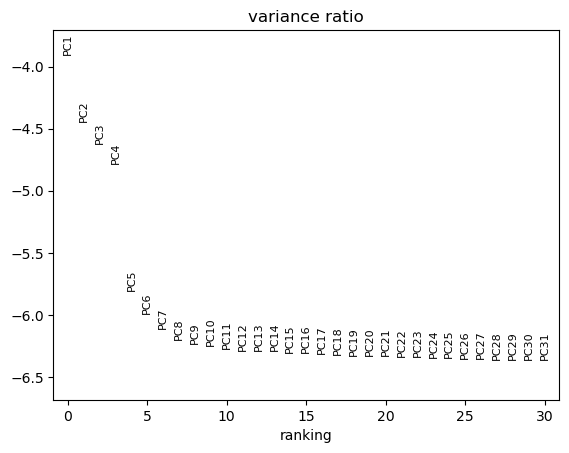

In [10]:
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=True)

In [4]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

computing neighbors
    computing neighbors
    using 'X_pca' with n_pcs = 40


c:\Users\billn\.conda\envs\scrna\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


    computed neighbors (0:00:03)


c:\Users\billn\.conda\envs\scrna\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    computed connectivities (0:00:06)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:09)


In [5]:
sc.tl.umap(adata)

computing UMAP


 12%|█▏        | 59/500 [00:00<00:04, 106.62it/s]

	completed  0  /  500 epochs
	completed  50  /  500 epochs


 29%|██▊       | 143/500 [00:01<00:01, 204.83it/s]

	completed  100  /  500 epochs
	completed  150  /  500 epochs


...

	completed  300  /  500 epochs
	completed  350  /  500 epochs


 86%|████████▌ | 428/500 [00:02<00:00, 276.66it/s]

	completed  400  /  500 epochs
	completed  450  /  500 epochs


100%|██████████| 500/500 [00:02<00:00, 209.27it/s]

    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:02)


In [6]:
sc.tl.leiden(adata, resolution=0.5)

running Leiden clustering


C:\Users\billn\AppData\Local\Temp\ipykernel_22660\1771924308.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5)


    finished: found 6 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


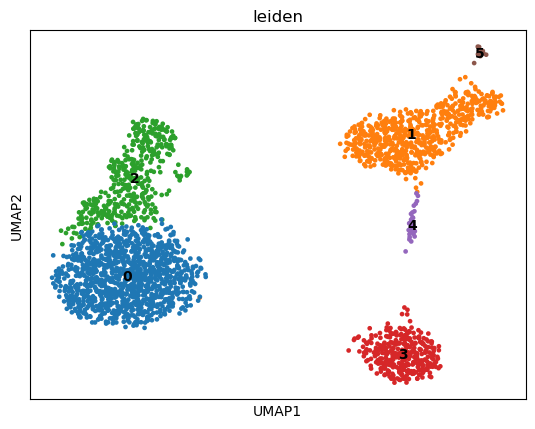

In [7]:
sc.pl.umap(adata, color=['leiden'], legend_loc='on data')

In [8]:
adata.write('../data/pbmc3k_clustered.h5ad')
print("Saved successfully")
print(adata)

Saved successfully
AnnData object with n_obs × n_vars = 2638 × 1826
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'
